In [1]:
from pathlib import Path
import json
from typing import cast, Dict
import testing
from run_types import CompRes, TopKRes


In [2]:
exps_dict_path = Path('./results/wlasl_satnac_16_only.json')
print(exps_dict_path.exists())

True


In [3]:
split = 'asl100'

In [4]:
with open(exps_dict_path, 'r') as f:
    exps_dict = json.load(f)
asl100_exps = exps_dict[split]
print(len(asl100_exps))

8


In [5]:
runs_dir = Path('./runs') / split

In [6]:
summarised = {}
for model_name, exps in asl100_exps.items():
    expno = exps[0]
    print(f'{model_name} : {expno}')
    
    res_key1 = "top_k_average_per_class_acc"
    res_key2 = "top_k_per_instance_acc"
    
    
    try:
        results_path_modern = runs_dir / f'{model_name}_exp{expno}' / 'results' / 'best_val_loss.json'
        
        with open(results_path_modern, 'r') as f:
            entry_res = cast(CompRes, json.load(f))
            
        summarised[model_name] = {
            'exp': expno,
            res_key1 : entry_res['test'][res_key1],
            res_key2 : entry_res['test'][res_key2]
        }
    except FileNotFoundError:
        results_path_back_compatibility = runs_dir / f'{model_name}_exp{expno}' / 'results' / 'best_test-top-k.json'

        with open(results_path_back_compatibility, 'r') as f:
            entry_res = cast(Dict[str, TopKRes], json.load(f))
            
        summarised[model_name] = {
            'exp': expno,
            res_key1 : entry_res[res_key1],
            res_key2 : entry_res[res_key2]
        }
    


exps_summarised_dict_path = Path('./results/wlasl_satnac_16_only_summarised.json')
with open(exps_summarised_dict_path, 'w') as f:
    json.dump({split: summarised}, f, indent=4)
    

    

Resnet3D_18 : 005
Resnet2D_1D_18 : 006
S3D : 012
MViT_V1_B : 000
MViT_V2_S : 004
Swin3D_B : 002
Swin3D_S : 002
Swin3D_T : 002


dict_keys(['asl100'])


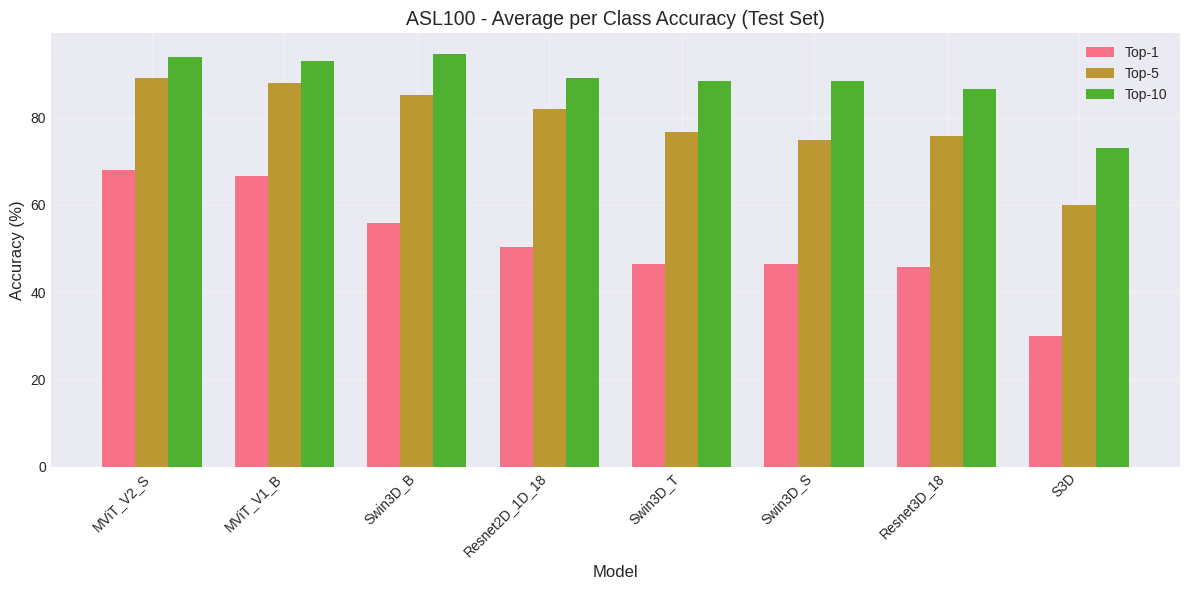

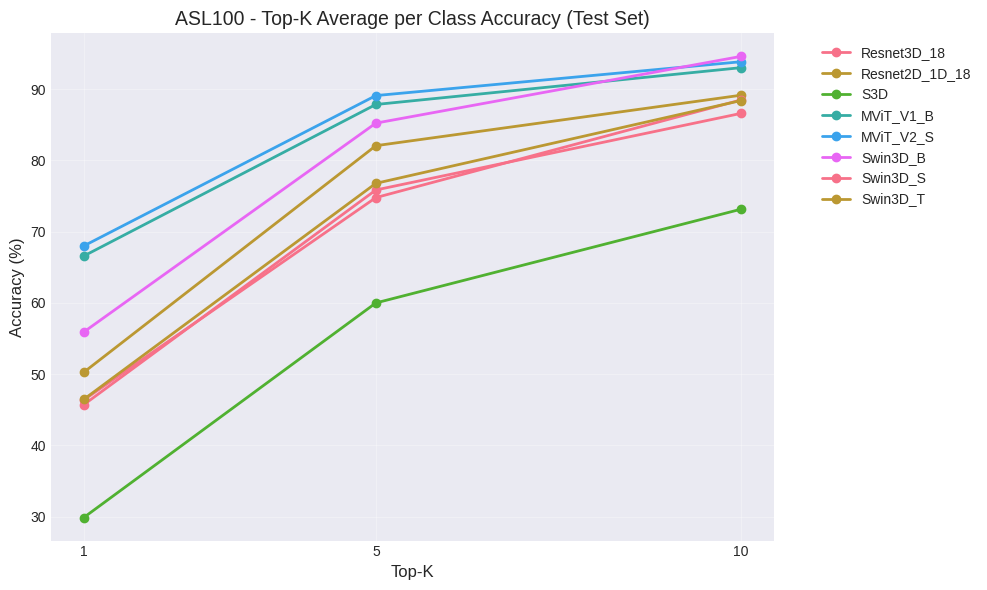

In [8]:
import visualise
df, results = visualise.run_visualizations('./results/wlasl_satnac_16_only_summary.json', extractor=visualise.extract_metrics_df_sumed, splits=[split])

dict_keys(['asl100'])


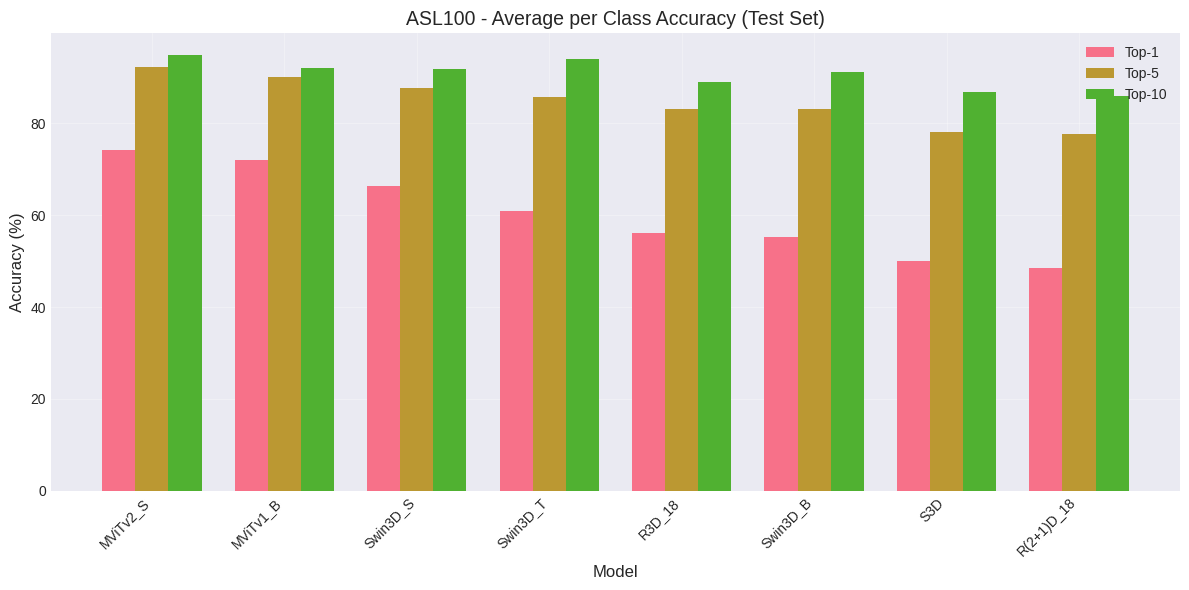

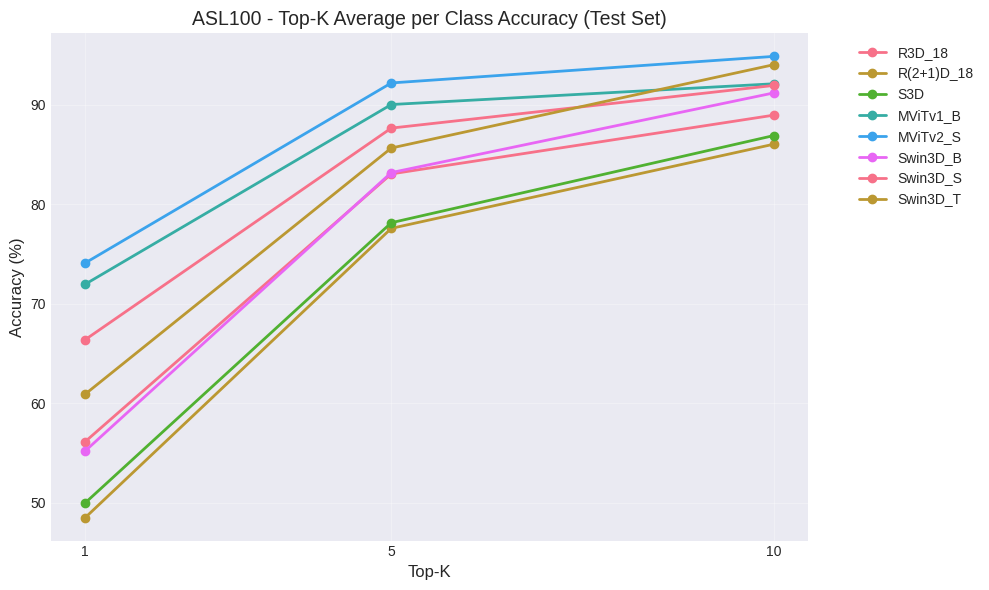

In [9]:
df, results = visualise.run_visualizations('./results/wlasl_satnac_16_only_improved_summarised.json', extractor=visualise.extract_metrics_df_sumed, splits=[split])

In [14]:
latex_titles = {
    "top_k_average_per_class_acc": "Mean er-Class",
    "top_k_per_instance_acc": "Per instance"
}
acc_key = "top_k_per_instance_acc"
def print_latex_table(total_summarised):
    # LaTeX boilerplate header
    latex_str = f"""\\begin{{table}}[htbp]
\\centering
\\caption{{{latex_titles[acc_key]} top-$k$ accuracy (\\%) across all WLASL splits under the tuned hyperparameter configuration.}}
\\label{{tab:main_res}}
\\begin{{tabular}}{{|l|l|ccc|}}
\\hline
\\textbf{{Split}} & \\textbf{{Model}} & \\textbf{{Acc@1}} & \\textbf{{Acc@5}} & \\textbf{{Acc@10}} \\\\
\\hline"""

    # Iterate over each split in the data
    for split, split_data in total_summarised.items():
        # Format "asl100" -> "WLASL100"
        split_name = split.replace('asl', 'WLASL')
        models = list(split_data.keys())

        print(split)
        print(split_data)


        # Identify maximum values in the current split for bolding
        max_top1 = max(split_data[m][acc_key]["top1"] for m in models)
        max_top5 = max(split_data[m][acc_key]["top5"] for m in models)
        max_top10 = max(split_data[m][acc_key]["top10"] for m in models)

        for i, model in enumerate(models):
            # Escape underscore for LaTeX
            model_name = model.replace('_', '\\_')
            metrics = split_data[model][acc_key]

            # Convert to percentages and format to 2 decimal places
            top1_str = f"{metrics['top1'] * 100:.2f}"
            top5_str = f"{metrics['top5'] * 100:.2f}"
            top10_str = f"{metrics['top10'] * 100:.2f}"

            # Apply bold formatting to the best values
            if metrics['top1'] == max_top1:
                top1_str = f"\\textbf{{{top1_str}}}"
            if metrics['top5'] == max_top5:
                top5_str = f"\\textbf{{{top5_str}}}"
            if metrics['top10'] == max_top10:
                top10_str = f"\\textbf{{{top10_str}}}"

            # Only print the split name on the first row of the group
            col1_text = split_name if i == 0 else ""
            
            # Format row with consistent spacing for clean raw LaTeX code
            row = f"{col1_text:<9} & {model_name:<10} & {top1_str:<14} & {top5_str:<14} & {top10_str} \\\\"
            latex_str += "\n" + row

        latex_str += "\n\\hline"

    # LaTeX boilerplate footer
    latex_str += """
\\end{tabular}
\\end{table}"""

    print(latex_str)

# Call the function
print_latex_table({"asl100": summarised})


asl100
{'Resnet3D_18': {'exp': '005', 'top_k_average_per_class_acc': {'top1': 0.45699999999999996, 'top5': 0.7583333333333333, 'top10': 0.8658333333333332}, 'top_k_per_instance_acc': {'top1': 0.46124031007751937, 'top5': 0.7596899224806202, 'top10': 0.8682170542635659}}, 'Resnet2D_1D_18': {'exp': '006', 'top_k_average_per_class_acc': {'top1': 0.5025, 'top5': 0.8204999999999998, 'top10': 0.8913333333333333}, 'top_k_per_instance_acc': {'top1': 0.5038759689922481, 'top5': 0.8178294573643411, 'top10': 0.8914728682170543}}, 'S3D': {'exp': '012', 'top_k_average_per_class_acc': {'top1': 0.29866666666666664, 'top5': 0.5998333333333333, 'top10': 0.7313333333333333}, 'top_k_per_instance_acc': {'top1': 0.29844961240310075, 'top5': 0.5968992248062015, 'top10': 0.7286821705426356}}, 'MViT_V1_B': {'exp': '000', 'top_k_average_per_class_acc': {'top1': 0.6656666666666666, 'top5': 0.8783333333333333, 'top10': 0.93}, 'top_k_per_instance_acc': {'top1': 0.6550387596899225, 'top5': 0.875968992248062, 'top1

In [13]:

print(summarised['Resnet3D_18'].keys())

dict_keys(['exp', 'top_k_average_per_class_acc', 'top_k_per_instance_acc'])
